# 📊 ROOT DEWAR Analysis - 18/12/2025

**Experiment: Measurement WITHOUT ferrule to verify thermal sensitivities**

**Experimental phases:**
- **Phase 1 - Initial heating**: 16:11h to 16:32h  
- **Phase 2 - Cooling**: 17:32h to 19:10h

**Analyzed sensors**: 1, 2, 3, 4 (indices 0-3)

ROOT file: `20251218.root`

## 1️⃣ Data loading and initial diagnostics

In [ ]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Plot configuration
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# ROOT file
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251218.root"

print("🔍 Loading data...")
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

print("\n=== DATA DIMENSIONS ===")
print(f"Peak entries: {len(peak_data['t']):,}")
print(f"Temp entries: {len(temp_data['t']):,}")
print(f"\nPeak shapes:")
for key, value in peak_data.items():
    print(f"  {key}: {np.array(value).shape}")
print(f"\nTemp shapes:")
for key, value in temp_data.items():
    print(f"  {key}: {np.array(value).shape}")

# Convert timestamps and apply +2h correction to peaks
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

time_shift = datetime.timedelta(hours=2)
peak_times = peak_times + time_shift

print(f"\n⏰ TIME RANGES (peaks with +2h correction):")
print(f"  Peak: {peak_times.min()} → {peak_times.max()}")
print(f"  Temp: {temp_times.min()} → {temp_times.max()}")
print(f"  Total duration: {peak_times.max() - peak_times.min()}")

🔍 Loading data...

=== DATA DIMENSIONS ===
Peak entries: 899,125
Temp entries: 5,464

Peak shapes:
  t: (899125, 2)
  wav: (899125, 2, 4)

=== DATA DIMENSIONS ===
Peak entries: 899,125
Temp entries: 5,464

Peak shapes:
  t: (899125, 2)
  wav: (899125, 2, 4)
  sweep: (899125, 2, 4)
  ch: (899125, 4)
  pos: (899125, 4)

Temp shapes:
  t: (5464,)
  temp: (5464, 5)
  sweep: (899125, 2, 4)
  ch: (899125, 4)
  pos: (899125, 4)

Temp shapes:
  t: (5464,)
  temp: (5464, 5)

⏰ TIME RANGES (peaks with +2h correction):
  Peak: 2025-12-03 12:11:36.957274914 → 2025-12-03 14:11:29.956864119
  Temp: 2025-12-03 12:10:11 → 2025-12-03 14:10:04
  Total duration: 0 days 01:59:52.999589205

⏰ TIME RANGES (peaks with +2h correction):
  Peak: 2025-12-03 12:11:36.957274914 → 2025-12-03 14:11:29.956864119
  Temp: 2025-12-03 12:10:11 → 2025-12-03 14:10:04
  Total duration: 0 days 01:59:52.999589205


## 2️⃣ Overview: ALL sensors (both polarizations + temperature)

Visualization of the complete experiment for the 4 sensors, showing:
- Both polarizations of λB
- Temperature
- Filtering of zero/null values
- Markers for the 3 experimental phases

/tmp/vgarciap/ipykernel_3412639/170673050.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


✅ Wavelength evolution plot generated


/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


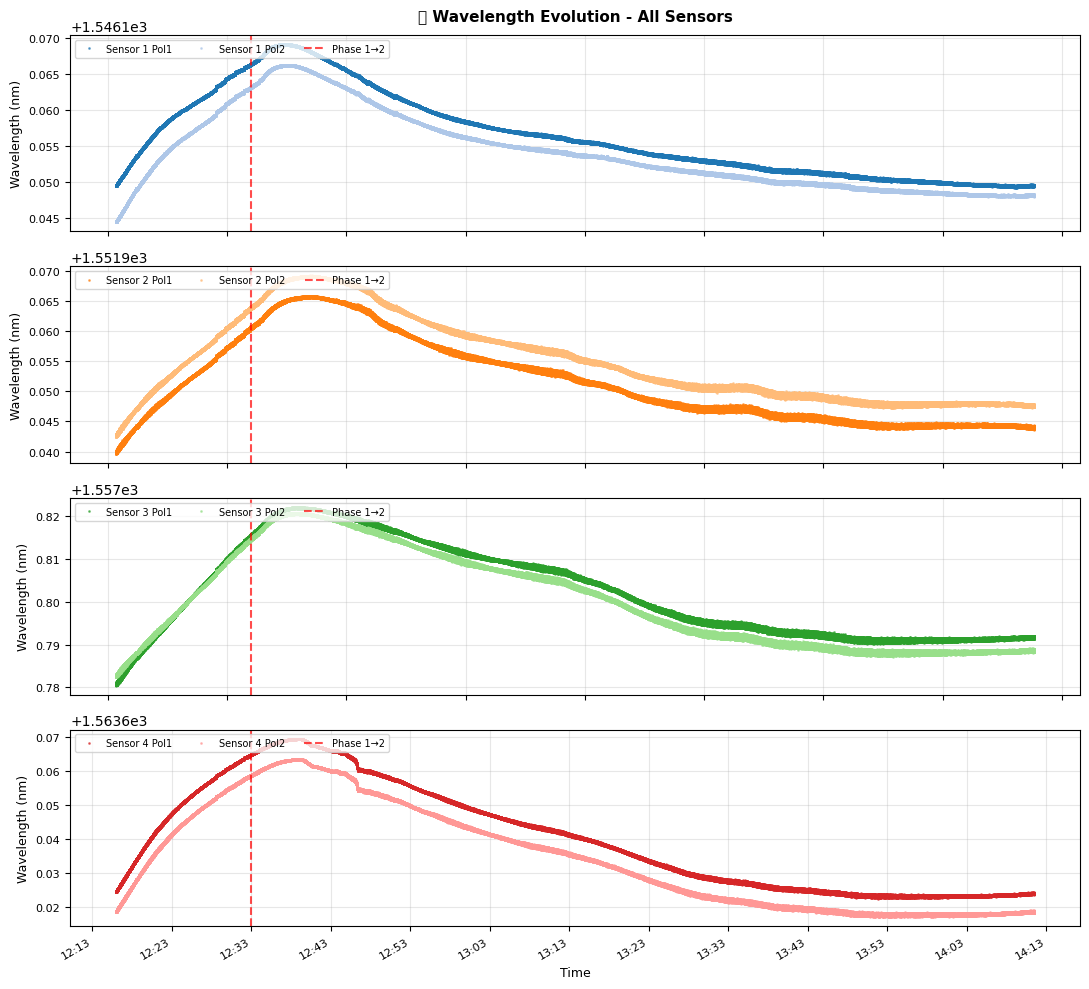

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import datetime
from IPython.display import display

# Sensors to analyze (indices 0-3, only 4 sensors in this experiment)
sensors = [0, 1, 2, 3]
sensor_names = ["Sensor 1", "Sensor 2", "Sensor 3", "Sensor 4"]
colors_pol1 = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
colors_pol2 = ["#aec7e8", "#ffbb78", "#98df8a", "#ff9896"]
colors_temp = ["#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
colors_mean = ["#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

# Filter initial transient: skip first 5 minutes of data
filter_start_time = datetime.datetime(2025, 12, 18, 16, 16, 0)  # Start at 12:16
time_mask_peak = peak_times >= filter_start_time
time_mask_temp = temp_times >= filter_start_time

# Create filtered time arrays
peak_times_valid = peak_times[time_mask_peak]
temp_times_valid = temp_times[time_mask_temp]

# Create figure with subplots - NO constrained_layout (causes conflicts)
fig, axes = plt.subplots(4, 1, figsize=(11, 10))

# Phase marker: transition from heating to cooling
phase_transition = datetime.datetime(2025, 12, 18, 16, 33)

for idx, sensor_idx in enumerate(sensors):
    ax1 = axes[idx]
    
    # Extract polarization data
    pol1 = peak_data["wav"][:, 0, sensor_idx] * 1e9  # m → nm
    pol2 = peak_data["wav"][:, 1, sensor_idx] * 1e9
    
    # Filter transients
    pol1_filtered = pol1[time_mask_peak]
    pol2_filtered = pol2[time_mask_peak]
    
    # Plot polarization data
    ax1.plot(peak_times_valid, pol1_filtered, 'o', 
             markersize=1.0, alpha=0.6, color=colors_pol1[idx], label=f'{sensor_names[idx]} Pol1')
    ax1.plot(peak_times_valid, pol2_filtered, 'o', 
             markersize=1.0, alpha=0.6, color=colors_pol2[idx], label=f'{sensor_names[idx]} Pol2')
    
    # Phase transition marker
    ax1.axvline(phase_transition, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Phase 1→2')
    
    # Configure subplot
    ax1.set_ylabel('Wavelength (nm)', fontsize=9)
    ax1.legend(loc='upper left', fontsize=7, ncol=3)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=8)
    
    if idx == 0:
        ax1.set_title('📊 Wavelength Evolution - All Sensors', fontsize=11, fontweight='bold', pad=10)
    if idx < 3:
        ax1.set_xticklabels([])
    else:
        ax1.set_xlabel('Time', fontsize=9)
        # Format x-axis time labels
        import matplotlib.dates as mdates
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
        fig.autofmt_xdate()

plt.tight_layout()
print("✅ Wavelength evolution plot generated")


## 📊 Mean Polarization and Temperature Overlay

This plot shows the average wavelength of both polarizations alongside the temperature measurements for each sensor.

/tmp/vgarciap/ipykernel_3412639/1029468965.py:68: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


✅ Mean wavelength and temperature overlay plot generated


/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


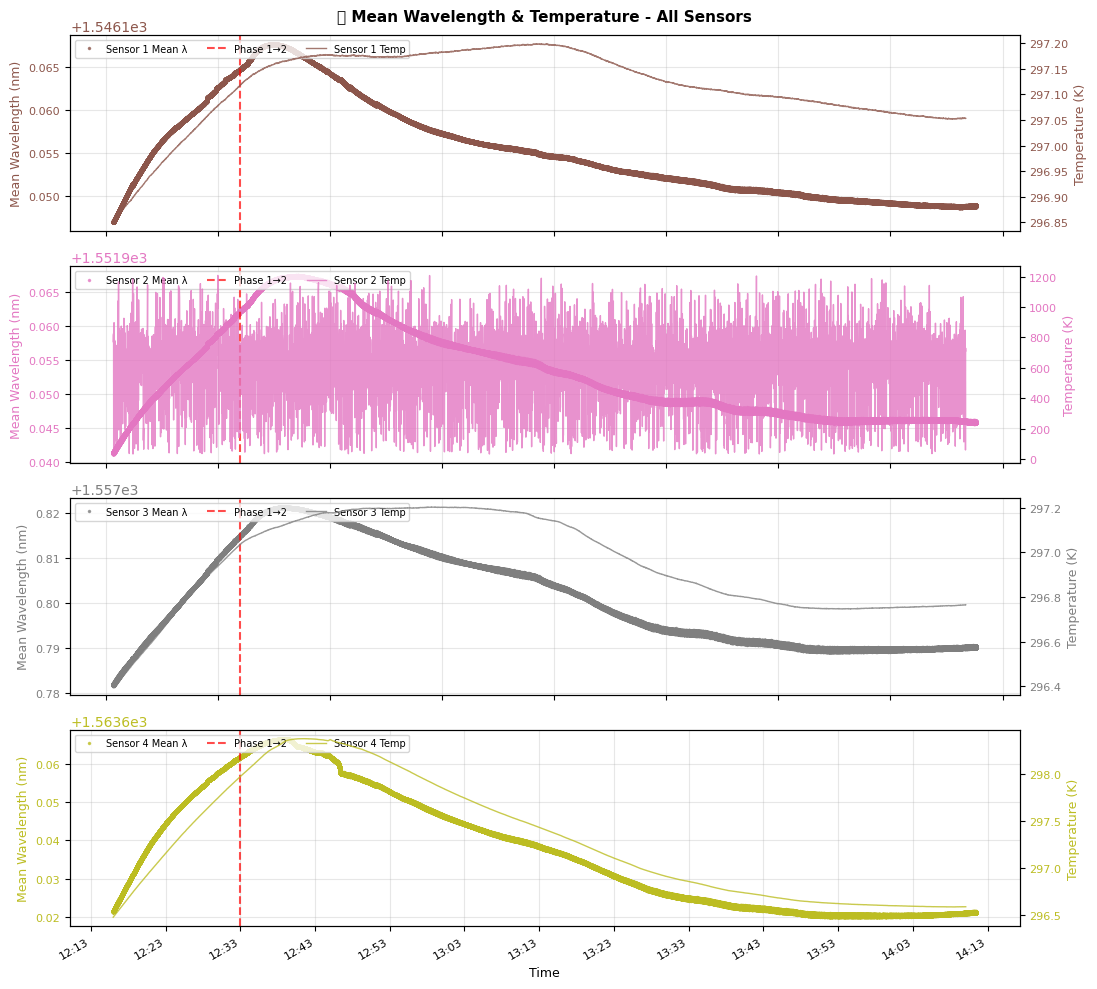

In [3]:
# Create figure with dual-axis subplots for mean polarization and temperature
fig2, axes2 = plt.subplots(4, 1, figsize=(11, 10))

for idx, sensor_idx in enumerate(sensors):
    ax_pol = axes2[idx]
    
    # Extract polarization data
    pol1 = peak_data["wav"][:, 0, sensor_idx] * 1e9  # m → nm
    pol2 = peak_data["wav"][:, 1, sensor_idx] * 1e9
    
    # Filter transients
    pol1_filtered = pol1[time_mask_peak]
    pol2_filtered = pol2[time_mask_peak]
    
    # Calculate mean polarization
    pol_mean = (pol1_filtered + pol2_filtered) / 2
    
    # Plot mean polarization on primary axis
    ax_pol.plot(peak_times_valid, pol_mean, 'o', 
                markersize=1.5, alpha=0.7, color=colors_mean[idx], 
                label=f'{sensor_names[idx]} Mean λ')
    
    # Create secondary axis for temperature
    ax_temp = ax_pol.twinx()
    
    # Extract and filter temperature data
    temp = temp_data["temp"][:, sensor_idx]
    temp_filtered = temp[time_mask_temp]
    
    # Plot temperature on secondary axis
    ax_temp.plot(temp_times_valid, temp_filtered, '-', 
                 linewidth=1.0, alpha=0.8, color=colors_temp[idx], 
                 label=f'{sensor_names[idx]} Temp')
    
    # Phase transition marker
    ax_pol.axvline(phase_transition, color='red', linestyle='--', 
                   linewidth=1.5, alpha=0.7, label='Phase 1→2')
    
    # Configure primary axis (wavelength)
    ax_pol.set_ylabel('Mean Wavelength (nm)', fontsize=9, color=colors_mean[idx])
    ax_pol.tick_params(axis='y', labelcolor=colors_mean[idx], labelsize=8)
    ax_pol.tick_params(axis='x', labelsize=8)
    ax_pol.grid(True, alpha=0.3)
    
    # Configure secondary axis (temperature)
    ax_temp.set_ylabel('Temperature (K)', fontsize=9, color=colors_temp[idx])
    ax_temp.tick_params(axis='y', labelcolor=colors_temp[idx], labelsize=8)
    
    # Combine legends
    lines1, labels1 = ax_pol.get_legend_handles_labels()
    lines2, labels2 = ax_temp.get_legend_handles_labels()
    ax_pol.legend(lines1 + lines2, labels1 + labels2, 
                  loc='upper left', fontsize=7, ncol=3)
    
    if idx == 0:
        ax_pol.set_title('🌡️ Mean Wavelength & Temperature - All Sensors', 
                         fontsize=11, fontweight='bold', pad=10)
    if idx < 3:
        ax_pol.set_xticklabels([])
    else:
        ax_pol.set_xlabel('Time', fontsize=9)
        # Format x-axis time labels
        import matplotlib.dates as mdates
        ax_pol.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax_pol.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
        fig2.autofmt_xdate()

plt.tight_layout()
print("✅ Mean wavelength and temperature overlay plot generated")

### 📊 Overview with Mean Polarization

Same view as above, but showing the **mean of both polarizations** instead of plotting them separately.

## 🔥 Phase 1: Heating (16:16h - 16:33h)

Analysis of the **heating phase** - approximately 17 minutes of temperature increase.

PHASE 1: HEATING (12:16h - 12:33h)
Time window: 2025-12-03 12:16:00 → 2025-12-03 12:33:00
Duration: ~17 minutes
Filtered peak data: 127,500 points
Filtered temp data: 771 points
⚠️  Sensor 2 excluded from analysis (corrupted temperature)

───── Sensor 1 ─────
Valid λB points: 127500/127500
Valid Temp points: 771/771
Resampled data: 17 points
Sensitivity: 63.62 ± 1.61 pm/K
R²: 0.9904

───── Sensor 3 ─────
Valid λB points: 127500/127500
Valid Temp points: 771/771
Resampled data: 17 points
Sensitivity: 50.41 ± 0.45 pm/K
R²: 0.9988

───── Sensor 4 ─────
Valid λB points: 127500/127500
Valid Temp points: 771/771
Resampled data: 17 points
Sensitivity: 26.37 ± 0.82 pm/K
R²: 0.9856


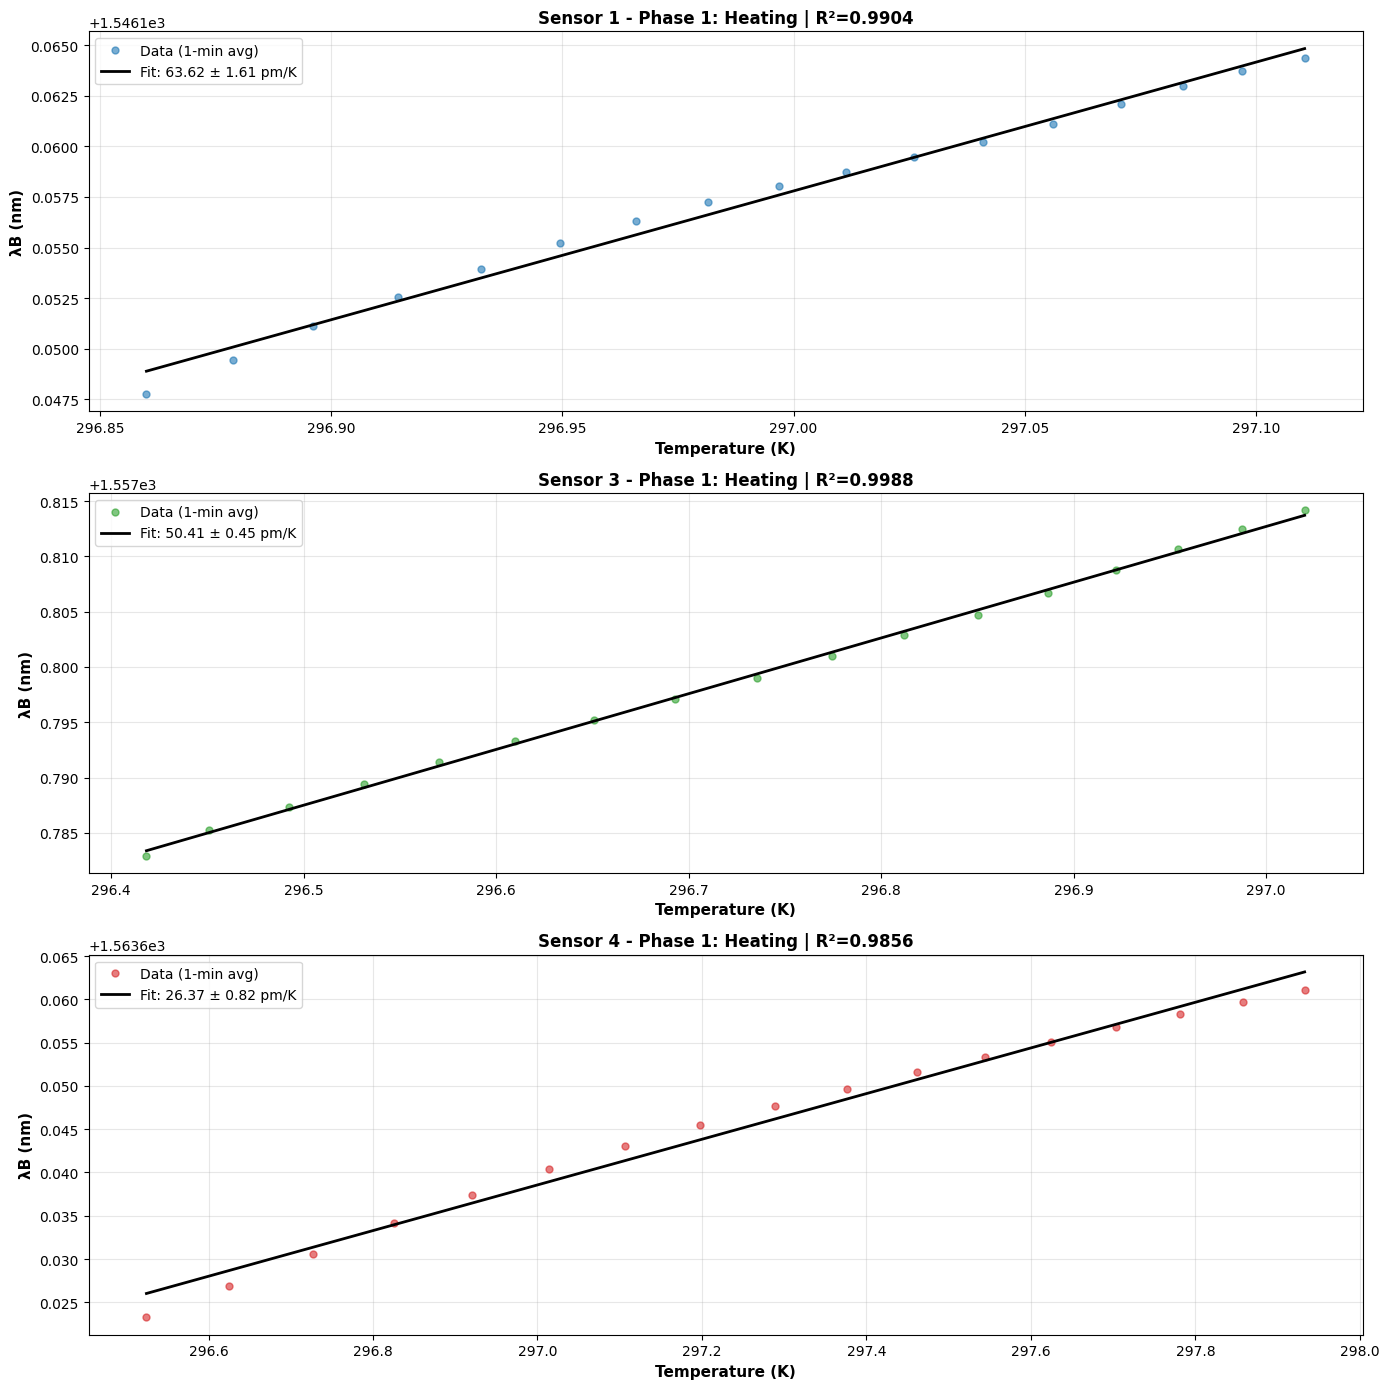


✅ Phase 1 (Heating) analysis completed
   (Sensor 2 excluded - corrupted temperature)


In [ ]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from IPython.display import display

# Sensors and colors (consistent palette) - EXCLUDING Sensor 2 (corrupted temp)
sensors = [0, 2, 3]  # Sensor 1, 3, 4 only
sensor_names = ["Sensor 1", "Sensor 3", "Sensor 4"]
colors = ["#1f77b4", "#2ca02c", "#d62728"]  # Blue, Green, Red

# Time window PHASE 1: Heating phase
start_time = datetime.datetime(2025, 12, 18, 16, 16, 0)  # Heating starts
end_time = datetime.datetime(2025, 12, 18, 16, 33, 0)    # Transition to cooling

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

print("="*70)
print("PHASE 1: HEATING (16:16h - 16:33h)")
print("="*70)
print(f"Time window: {start_time} → {end_time}")
print(f"Duration: ~17 minutes")
print(f"Filtered peak data: {mask_peak.sum():,} points")
print(f"Filtered temp data: {mask_temp.sum():,} points")
print(f"⚠️  Sensor 2 excluded from analysis (corrupted temperature)")

# Create figure (only 3 sensors)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

results_phase1 = []

for i, sensor_idx in enumerate(sensors):
    print(f"\n───── {sensor_names[i]} ─────")
    
    # λB: MEAN of both polarizations
    lambdaB_pol1_m = peak_data["wav"][mask_peak, 0, sensor_idx]
    lambdaB_pol2_m = peak_data["wav"][mask_peak, 1, sensor_idx]
    lambdaB_mean_m = (lambdaB_pol1_m + lambdaB_pol2_m) / 2.0
    lambdaB_nm = lambdaB_mean_m * 1e9  # m → nm
    
    # Temperature
    temp_sensor = temp_data["temp"][mask_temp, sensor_idx]
    
    # Filter valid data (non-zero, non-NaN)
    valid_lambda = (lambdaB_nm != 0) & (~np.isnan(lambdaB_nm))
    valid_temp = (temp_sensor > 0) & (~np.isnan(temp_sensor))
    
    print(f"Valid λB points: {valid_lambda.sum()}/{len(lambdaB_nm)}")
    print(f"Valid Temp points: {valid_temp.sum()}/{len(temp_sensor)}")
    
    # Extract valid data
    lambdaB_filtered = lambdaB_nm[valid_lambda]
    peak_t_sensor = peak_t_filtered[valid_lambda]
    temp_filtered = temp_sensor[valid_temp]
    temp_t_sensor = temp_t_filtered[valid_temp]
    
    if len(lambdaB_filtered) < 10 or len(temp_filtered) < 10:
        print(f"⚠️  Insufficient data for fit")
        continue
    
    # Resample to 1 minute
    df_peak = pd.DataFrame({'time': peak_t_sensor, 'lambda': lambdaB_filtered})
    df_temp = pd.DataFrame({'time': temp_t_sensor, 'temp': temp_filtered})
    
    df_peak.set_index('time', inplace=True)
    df_temp.set_index('time', inplace=True)
    
    peak_resampled = df_peak.resample('1min').mean()
    temp_resampled = df_temp.resample('1min').mean()
    
    # Combine
    df_combined = pd.merge(peak_resampled, temp_resampled, left_index=True, right_index=True, how='inner')
    df_combined = df_combined.dropna()
    
    print(f"Resampled data: {len(df_combined)} points")
    
    if len(df_combined) < 5:
        print("⚠️  Insufficient data after resampling")
        continue
    
    x = df_combined['temp'].values  # Temperature (K)
    y = df_combined['lambda'].values  # λB (nm)
    
    # Weighted linear fit
    yerr = np.ones_like(y) * 0.001  # Assume 1 pm uncertainty
    w = 1.0 / yerr**2
    
    # Fit: λB = a*T + b
    A = np.vstack([x, np.ones(len(x))]).T
    W = np.diag(w)
    coeffs = np.linalg.lstsq(W @ A, W @ y, rcond=None)[0]
    slope, intercept = coeffs
    
    # Convert to pm/K
    sensitivity_pm_K = slope * 1000  # nm/K → pm/K
    
    # Statistics
    y_fit = slope * x + intercept
    residuals = y - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Standard error
    n = len(x)
    std_err = np.sqrt(ss_res / (n - 2)) / np.sqrt(np.sum((x - np.mean(x))**2))
    std_err_pm_K = std_err * 1000
    
    print(f"Sensitivity: {sensitivity_pm_K:.2f} ± {std_err_pm_K:.2f} pm/K")
    print(f"R²: {r_squared:.4f}")
    
    results_phase1.append({
        'sensor': sensor_names[i],
        'sensitivity': sensitivity_pm_K,
        'std_err': std_err_pm_K,
        'r_squared': r_squared
    })
    
    # Plot
    ax = axes[i]
    ax.plot(x, y, 'o', color=colors[i], alpha=0.6, markersize=5, label='Data (1-min avg)')
    ax.plot(x, y_fit, '-', color='black', linewidth=2, 
            label=f'Fit: {sensitivity_pm_K:.2f} ± {std_err_pm_K:.2f} pm/K')
    
    ax.set_xlabel("Temperature (K)", fontsize=11, fontweight='bold')
    ax.set_ylabel("λB (nm)", fontsize=11, fontweight='bold')
    ax.set_title(f"{sensor_names[i]} - Phase 1: Heating | R²={r_squared:.4f}", 
                fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
display(fig)
plt.close()

print("\n✅ Phase 1 (Heating) analysis completed")
print("   (Sensor 2 excluded - corrupted temperature)")

## ❄️ Phase 2: Cooling (16:33h - 18:10h)

Analysis of the **cooling phase** - approximately 97 minutes of temperature decrease.

PHASE 2: COOLING (12:33h - 14:10h)
Time window: 2025-12-03 12:33:00 → 2025-12-03 14:10:00
Duration: ~97 minutes
Filtered peak data: 727,499 points
Filtered temp data: 4,421 points
⚠️  Sensor 2 excluded from analysis (corrupted temperature)

───── Sensor 1 ─────
Valid λB points: 727499/727499
Valid Temp points: 4421/4421
Resampled data: 97 points
Sensitivity: 78.43 ± 9.05 pm/K
R²: 0.4416

───── Sensor 3 ─────
Valid λB points: 727499/727499
Valid Temp points: 4421/4421
Resampled data: 97 points
Sensitivity: 54.38 ± 2.74 pm/K
R²: 0.8051

───── Sensor 4 ─────
Valid λB points: 727499/727499
Valid Temp points: 4421/4421
Resampled data: 97 points
Sensitivity: 23.88 ± 0.41 pm/K
R²: 0.9733


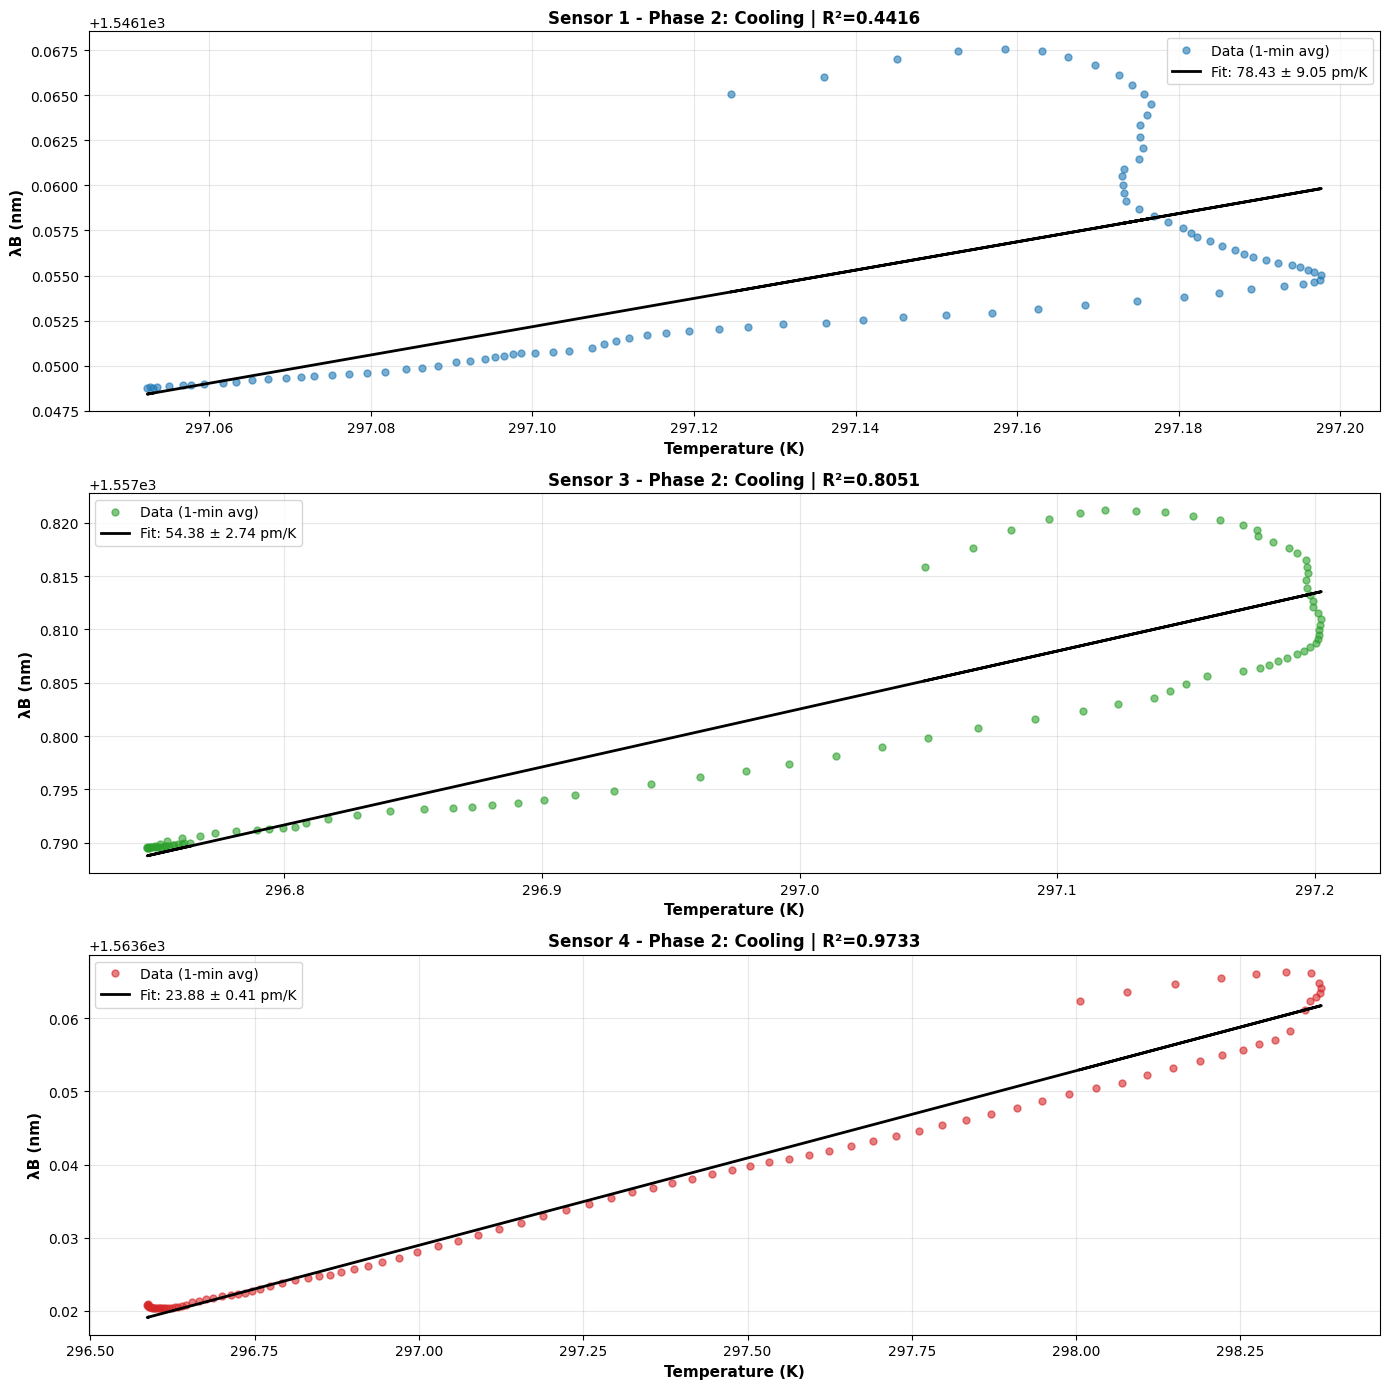


✅ Phase 2 (Cooling) analysis completed
   (Sensor 2 excluded - corrupted temperature)


In [ ]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from IPython.display import display

# Sensors and colors (consistent palette) - EXCLUDING Sensor 2 (corrupted temp)
sensors = [0, 2, 3]  # Sensor 1, 3, 4 only
sensor_names = ["Sensor 1", "Sensor 3", "Sensor 4"]
colors = ["#1f77b4", "#2ca02c", "#d62728"]  # Blue, Green, Red

# Time window PHASE 2: Cooling phase
start_time = datetime.datetime(2025, 12, 18, 16, 33, 0)  # Cooling starts
end_time = datetime.datetime(2025, 12, 18, 18, 10, 0)    # End of experiment

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

print("="*70)
print("PHASE 2: COOLING (12:33h - 14:10h)")
print("="*70)
print(f"Time window: {start_time} → {end_time}")
print(f"Duration: ~97 minutes")
print(f"Filtered peak data: {mask_peak.sum():,} points")
print(f"Filtered temp data: {mask_temp.sum():,} points")
print(f"⚠️  Sensor 2 excluded from analysis (corrupted temperature)")

# Create figure (only 3 sensors)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

results_phase2 = []

for i, sensor_idx in enumerate(sensors):
    print(f"\n───── {sensor_names[i]} ─────")
    
    # λB: MEAN of both polarizations
    lambdaB_pol1_m = peak_data["wav"][mask_peak, 0, sensor_idx]
    lambdaB_pol2_m = peak_data["wav"][mask_peak, 1, sensor_idx]
    lambdaB_mean_m = (lambdaB_pol1_m + lambdaB_pol2_m) / 2.0
    lambdaB_nm = lambdaB_mean_m * 1e9  # m → nm
    
    # Temperature
    temp_sensor = temp_data["temp"][mask_temp, sensor_idx]
    
    # Filter valid data (non-zero, non-NaN)
    valid_lambda = (lambdaB_nm != 0) & (~np.isnan(lambdaB_nm))
    valid_temp = (temp_sensor > 0) & (~np.isnan(temp_sensor))
    
    print(f"Valid λB points: {valid_lambda.sum()}/{len(lambdaB_nm)}")
    print(f"Valid Temp points: {valid_temp.sum()}/{len(temp_sensor)}")
    
    # Extract valid data
    lambdaB_filtered = lambdaB_nm[valid_lambda]
    peak_t_sensor = peak_t_filtered[valid_lambda]
    temp_filtered = temp_sensor[valid_temp]
    temp_t_sensor = temp_t_filtered[valid_temp]
    
    if len(lambdaB_filtered) < 10 or len(temp_filtered) < 10:
        print(f"⚠️  Insufficient data for fit")
        continue
    
    # Resample to 1 minute
    df_peak = pd.DataFrame({'time': peak_t_sensor, 'lambda': lambdaB_filtered})
    df_temp = pd.DataFrame({'time': temp_t_sensor, 'temp': temp_filtered})
    
    df_peak.set_index('time', inplace=True)
    df_temp.set_index('time', inplace=True)
    
    peak_resampled = df_peak.resample('1min').mean()
    temp_resampled = df_temp.resample('1min').mean()
    
    # Combine
    df_combined = pd.merge(peak_resampled, temp_resampled, left_index=True, right_index=True, how='inner')
    df_combined = df_combined.dropna()
    
    print(f"Resampled data: {len(df_combined)} points")
    
    if len(df_combined) < 5:
        print("⚠️  Insufficient data after resampling")
        continue
    
    x = df_combined['temp'].values  # Temperature (K)
    y = df_combined['lambda'].values  # λB (nm)
    
    # Weighted linear fit
    yerr = np.ones_like(y) * 0.001  # Assume 1 pm uncertainty
    w = 1.0 / yerr**2
    
    # Fit: λB = a*T + b
    A = np.vstack([x, np.ones(len(x))]).T
    W = np.diag(w)
    coeffs = np.linalg.lstsq(W @ A, W @ y, rcond=None)[0]
    slope, intercept = coeffs
    
    # Convert to pm/K
    sensitivity_pm_K = slope * 1000  # nm/K → pm/K
    
    # Statistics
    y_fit = slope * x + intercept
    residuals = y - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Standard error
    n = len(x)
    std_err = np.sqrt(ss_res / (n - 2)) / np.sqrt(np.sum((x - np.mean(x))**2))
    std_err_pm_K = std_err * 1000
    
    print(f"Sensitivity: {sensitivity_pm_K:.2f} ± {std_err_pm_K:.2f} pm/K")
    print(f"R²: {r_squared:.4f}")
    
    results_phase2.append({
        'sensor': sensor_names[i],
        'sensitivity': sensitivity_pm_K,
        'std_err': std_err_pm_K,
        'r_squared': r_squared
    })
    
    # Plot
    ax = axes[i]
    ax.plot(x, y, 'o', color=colors[i], alpha=0.6, markersize=5, label='Data (1-min avg)')
    ax.plot(x, y_fit, '-', color='black', linewidth=2, 
            label=f'Fit: {sensitivity_pm_K:.2f} ± {std_err_pm_K:.2f} pm/K')
    
    ax.set_xlabel("Temperature (K)", fontsize=11, fontweight='bold')
    ax.set_ylabel("λB (nm)", fontsize=11, fontweight='bold')
    ax.set_title(f"{sensor_names[i]} - Phase 2: Cooling | R²={r_squared:.4f}", 
                fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
display(fig)
plt.close()

print("\n✅ Phase 2 (Cooling) analysis completed")
print("   (Sensor 2 excluded - corrupted temperature)")

## 🔥➡️❄️ Delayed Cooling Analysis (From 16:50h)

**Important observation:** Although we turned off the heater at **16:33h**, the system continued heating due to **thermal inertia**. The temperature reached a peak around **16:40-16:45h** before starting to cool down.

For a more accurate cooling fit, we analyze only the **true cooling phase starting at 16:50h**, after the thermal peak was reached and the system began its descent.

✅ Sensor 1: 58.38 ± 0.46 pm/K (R² = 0.7732, N = 4800)
✅ Sensor 3: 44.89 ± 0.16 pm/K (R² = 0.9450, N = 4800)
✅ Sensor 4: 21.33 ± 0.01 pm/K (R² = 0.9983, N = 4800)

📊 TRUE COOLING PHASE SENSITIVITY SUMMARY (12:50h - 14:10h)


/tmp/vgarciap/ipykernel_3412639/668742237.py:39: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  }).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:44: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  }).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:39: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  }).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:44: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  }).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:39: FutureWarning: 'S' is deprecated and will be removed in a future ve

,Sensor,Sensitivity (pm/K),Std Error (pm/K),R²,N_points
0,Sensor 1,58.375415,0.456408,0.773218,4800
1,Sensor 3,44.888837,0.156283,0.945039,4800
2,Sensor 4,21.331723,0.012884,0.998253,4800


/tmp/vgarciap/ipykernel_3412639/668742237.py:122: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_peak = pd.DataFrame({'time': peak_t_filtered, 'lambda': lambdaB_filtered}).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:123: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_temp = pd.DataFrame({'time': temp_t_filtered, 'temp': temp_filtered}).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:122: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_peak = pd.DataFrame({'time': peak_t_filtered, 'lambda': lambdaB_filtered}).set_index('time').resample('1S').mean().interpolate(method='linear')
/tmp/vgarciap/ipykernel_3412639/668742237.py:123: FutureWarning: 'S' is deprecated and will be removed in a future


✅ TRUE cooling phase visualization complete


/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/.venv/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


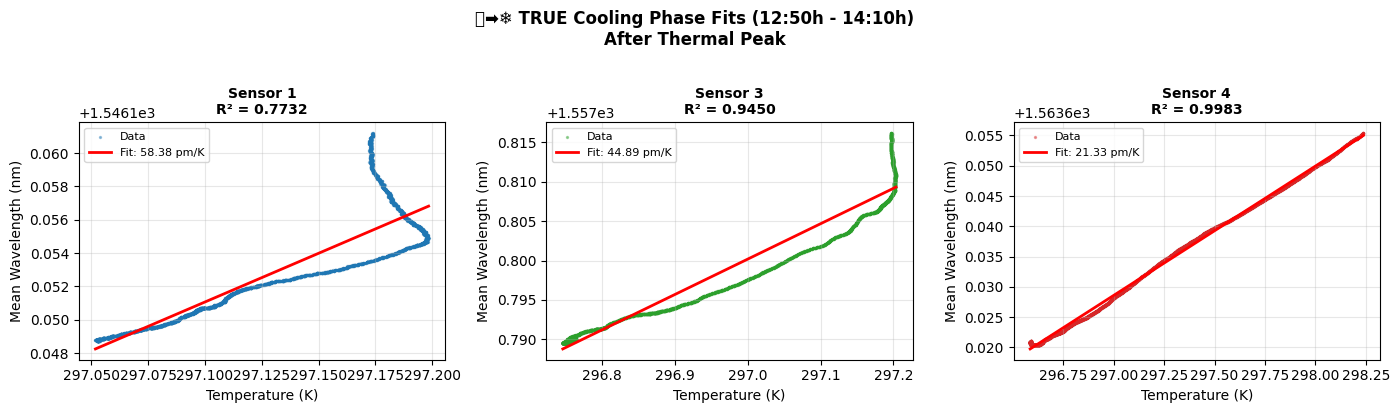

In [ ]:
# ========================================
# Cooling Phase Analysis - Starting at 12:50h
# (After thermal peak from residual heating)
# ========================================

# Define TRUE cooling start after thermal peak
cooling_true_start = datetime.datetime(2025, 12, 18, 16, 50, 0)
cooling_end = datetime.datetime(2025, 12, 18, 18, 10, 0)

# Sensors to analyze (excluding Sensor 2 - corrupted temperature)
sensors_cooling = [0, 2, 3]  # Sensor 1, 3, 4
sensor_names_cooling = ["Sensor 1", "Sensor 3", "Sensor 4"]
colors_cooling = ["#1f77b4", "#2ca02c", "#d62728"]

results_cooling_true = []

for idx, sensor_idx in enumerate(sensors_cooling):
    # Extract and filter data for TRUE cooling phase
    pol1 = peak_data["wav"][:, 0, sensor_idx] * 1e9
    pol2 = peak_data["wav"][:, 1, sensor_idx] * 1e9
    lambdaB_mean = (pol1 + pol2) / 2
    
    temp_sensor = temp_data["temp"][:, sensor_idx]
    
    # Time masks for TRUE cooling phase (12:50 - 14:10)
    mask_peak = (peak_times >= cooling_true_start) & (peak_times <= cooling_end)
    mask_temp = (temp_times >= cooling_true_start) & (temp_times <= cooling_end)
    
    # Apply filters
    lambdaB_filtered = lambdaB_mean[mask_peak]
    temp_filtered = temp_sensor[mask_temp]
    peak_t_filtered = peak_times[mask_peak]
    temp_t_filtered = temp_times[mask_temp]
    
    # Resample to 1-second intervals for alignment
    df_peak = pd.DataFrame({
        'time': peak_t_filtered,
        'lambda': lambdaB_filtered
    }).set_index('time').resample('1S').mean().interpolate(method='linear')
    
    df_temp = pd.DataFrame({
        'time': temp_t_filtered,
        'temp': temp_filtered
    }).set_index('time').resample('1S').mean().interpolate(method='linear')
    
    # Merge datasets
    df_combined = df_peak.join(df_temp, how='inner').dropna()
    
    if len(df_combined) < 10:
        print(f"⚠️  {sensor_names_cooling[idx]}: Insufficient data for TRUE cooling fit")
        continue
    
    x = df_combined['temp'].values
    y = df_combined['lambda'].values
    
    # Linear regression (weighted)
    n = len(x)
    W = np.ones(n)
    w = W / W.sum()
    
    x_mean = np.average(x, weights=w)
    y_mean = np.average(y, weights=w)
    
    slope = np.sum(w * (x - x_mean) * (y - y_mean)) / np.sum(w * (x - x_mean)**2)
    intercept = y_mean - slope * x_mean
    
    # Uncertainty estimation
    y_fit = slope * x + intercept
    residuals = y - y_fit
    ss_res = np.sum(w * residuals**2)
    ss_tot = np.sum(w * (y - y_mean)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    std_err = np.sqrt(ss_res / (n - 2))
    slope_err = std_err * np.sqrt(1 / np.sum(w * (x - x_mean)**2))
    
    sensitivity_pm_K = slope * 1e3  # nm → pm/K
    std_err_pm_K = slope_err * 1e3
    
    results_cooling_true.append({
        'Sensor': sensor_names_cooling[idx],
        'Sensitivity (pm/K)': sensitivity_pm_K,
        'Std Error (pm/K)': std_err_pm_K,
        'R²': r_squared,
        'N_points': n
    })
    
    print(f"✅ {sensor_names_cooling[idx]}: {sensitivity_pm_K:.2f} ± {std_err_pm_K:.2f} pm/K (R² = {r_squared:.4f}, N = {n})")

# Results DataFrame
df_cooling_true = pd.DataFrame(results_cooling_true)

print("\n" + "="*70)
print("📊 TRUE COOLING PHASE SENSITIVITY SUMMARY (16:50h - 18:10h)")
print("="*70)
display(df_cooling_true)

# ========================================
# Visualization: Fit Comparison
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, sensor_idx in enumerate(sensors_cooling):
    ax = axes[idx]
    
    # Extract data
    pol1 = peak_data["wav"][:, 0, sensor_idx] * 1e9
    pol2 = peak_data["wav"][:, 1, sensor_idx] * 1e9
    lambdaB_mean = (pol1 + pol2) / 2
    temp_sensor = temp_data["temp"][:, sensor_idx]
    
    mask_peak = (peak_times >= cooling_true_start) & (peak_times <= cooling_end)
    mask_temp = (temp_times >= cooling_true_start) & (temp_times <= cooling_end)
    
    lambdaB_filtered = lambdaB_mean[mask_peak]
    temp_filtered = temp_sensor[mask_temp]
    peak_t_filtered = peak_times[mask_peak]
    temp_t_filtered = temp_times[mask_temp]
    
    # Resample and merge
    df_peak = pd.DataFrame({'time': peak_t_filtered, 'lambda': lambdaB_filtered}).set_index('time').resample('1S').mean().interpolate(method='linear')
    df_temp = pd.DataFrame({'time': temp_t_filtered, 'temp': temp_filtered}).set_index('time').resample('1S').mean().interpolate(method='linear')
    df_combined = df_peak.join(df_temp, how='inner').dropna()
    
    if len(df_combined) < 10:
        continue
    
    x = df_combined['temp'].values
    y = df_combined['lambda'].values
    
    # Fit parameters from results
    result = results_cooling_true[idx]
    slope = result['Sensitivity (pm/K)'] / 1e3
    intercept = np.mean(y) - slope * np.mean(x)
    
    # Plot
    ax.scatter(x, y, s=2, alpha=0.4, color=colors_cooling[idx], label='Data')
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit: {result["Sensitivity (pm/K)"]:.2f} pm/K')
    
    ax.set_xlabel('Temperature (K)', fontsize=10)
    ax.set_ylabel('Mean Wavelength (nm)', fontsize=10)
    ax.set_title(f'{sensor_names_cooling[idx]}\nR² = {result["R²"]:.4f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('🔥➡️❄️ TRUE Cooling Phase Fits (12:50h - 14:10h)\nAfter Thermal Peak', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
print("\n✅ TRUE cooling phase visualization complete")

## 📊 Phase Comparison

Comparison of thermal sensitivities between **Phase 1 (Heating)** and **Phase 2 (Cooling)**.

PHASE COMPARISON: Heating vs Cooling
⚠️  Sensor 2 excluded from comparison (corrupted temperature)

📊 Sensitivity Comparison (pm/K):
----------------------------------------------------------------------
Sensor          Phase 1 (Heat)       Phase 2 (Cool)       Δ (P2-P1)      
----------------------------------------------------------------------
Sensor 1         63.62 ±  1.61   78.43 ±  9.05  +14.81
Sensor 3         50.41 ±  0.45   54.38 ±  2.74   +3.96
Sensor 4         26.37 ±  0.82   23.88 ±  0.41   -2.49


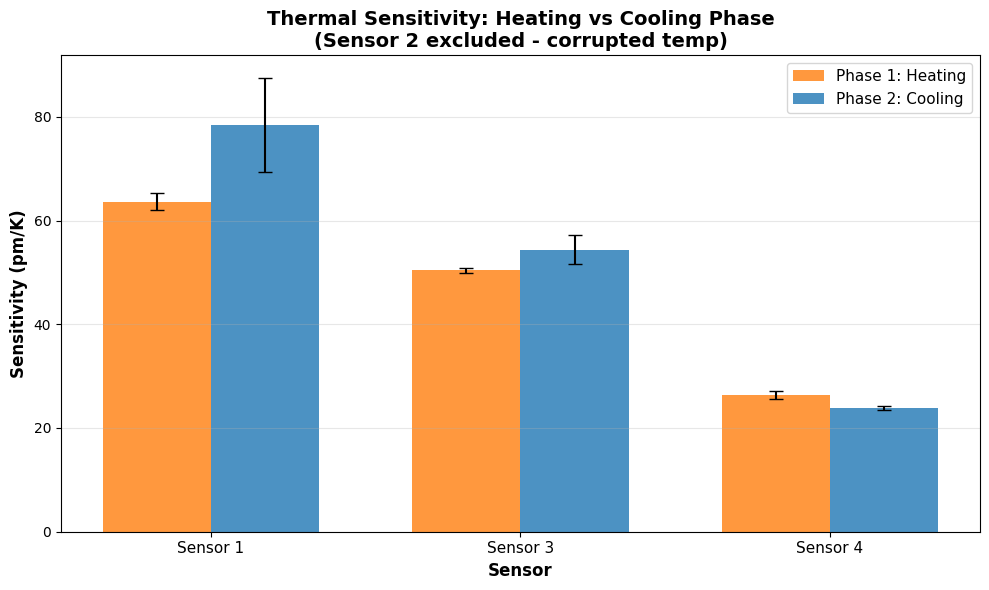


✅ Comparison completed for 3 sensors (Sensor 1, 3, 4)


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

print("="*70)
print("PHASE COMPARISON: Heating vs Cooling")
print("="*70)
print("⚠️  Sensor 2 excluded from comparison (corrupted temperature)")

# Check if results exist
if 'results_phase1' not in locals() or 'results_phase2' not in locals():
    print("\n⚠️  Please run Phase 1 and Phase 2 analysis cells first!")
    print("   Execute cells for Phase 1 and Phase 2 to generate results.")
else:
    # Create comparison DataFrame
    df_phase1 = pd.DataFrame(results_phase1)
    df_phase2 = pd.DataFrame(results_phase2)
    
    print("\n📊 Sensitivity Comparison (pm/K):")
    print("-" * 70)
    print(f"{'Sensor':<15} {'Phase 1 (Heat)':<20} {'Phase 2 (Cool)':<20} {'Δ (P2-P1)':<15}")
    print("-" * 70)
    
    for idx in range(len(df_phase1)):
        sensor = df_phase1.loc[idx, 'sensor']
        s1 = df_phase1.loc[idx, 'sensitivity']
        s2 = df_phase2.loc[idx, 'sensitivity']
        
        if np.isnan(s1) or np.isnan(s2):
            print(f"{sensor:<15} {'N/A':<20} {'N/A':<20} {'N/A':<15}")
        else:
            delta = s2 - s1
            print(f"{sensor:<15} {s1:>6.2f} ± {df_phase1.loc[idx, 'std_err']:>5.2f}  "
                  f"{s2:>6.2f} ± {df_phase2.loc[idx, 'std_err']:>5.2f}  {delta:>+6.2f}")
    
    # Bar chart comparison
    sensors_valid = []
    phase1_sens = []
    phase2_sens = []
    phase1_err = []
    phase2_err = []
    
    for idx in range(len(df_phase1)):
        s1 = df_phase1.loc[idx, 'sensitivity']
        s2 = df_phase2.loc[idx, 'sensitivity']
        if not (np.isnan(s1) or np.isnan(s2)):
            sensors_valid.append(df_phase1.loc[idx, 'sensor'])
            phase1_sens.append(s1)
            phase2_sens.append(s2)
            phase1_err.append(df_phase1.loc[idx, 'std_err'])
            phase2_err.append(df_phase2.loc[idx, 'std_err'])
    
    if len(sensors_valid) > 0:
        x = np.arange(len(sensors_valid))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(10, 6))
        bars1 = ax.bar(x - width/2, phase1_sens, width, yerr=phase1_err,
                       label='Phase 1: Heating', color='#ff7f0e', alpha=0.8, capsize=5)
        bars2 = ax.bar(x + width/2, phase2_sens, width, yerr=phase2_err,
                       label='Phase 2: Cooling', color='#1f77b4', alpha=0.8, capsize=5)
        
        ax.set_xlabel('Sensor', fontsize=12, fontweight='bold')
        ax.set_ylabel('Sensitivity (pm/K)', fontsize=12, fontweight='bold')
        ax.set_title('Thermal Sensitivity: Heating vs Cooling Phase\n(Sensor 2 excluded - corrupted temp)', 
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(sensors_valid, fontsize=11)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        display(fig)
        plt.close()
        
        print(f"\n✅ Comparison completed for {len(sensors_valid)} sensors (Sensor 1, 3, 4)")
    else:
        print("\n⚠️  No valid sensor data available for comparison")

---

## 📋 FINAL SUMMARY: Thermal Sensitivities EXPERIMENTO IGUAL PERO DEL DÍA 03

Complete summary table of all thermal sensitivity measurements from the experiment of **03/12/2025 (WITHOUT FERRULE)**.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("="*80)
print("🎯 THERMAL SENSITIVITY SUMMARY - EXPERIMENT 03/12/2025 (WITHOUT FERRULE)")
print("="*80)
print("📍 ANALYSIS FOCUSED ON SENSOR 4 (RED)")
print("="*80)
print()

# ========================================
# Compile all results into a master table
# Filter only Sensor 4 data
# ========================================

summary_data = []

# Phase 1: Heating (12:16 - 12:33) - Only Sensor 4
for result in results_phase1:
    if 'Sensor 4' in result['sensor']:
        summary_data.append({
            'Phase': 'Heating',
            'Time Range': '12:16 - 12:33',
            'Sensor': result['sensor'],
            'Sensitivity (pm/K)': result['sensitivity'],
            'Std Error (pm/K)': result['std_err'],
            'R²': result['r_squared'],
            'N Points': 'N/A'
        })

# Phase 2: Cooling (Full, 12:33 - 14:10) - Only Sensor 4
for result in results_phase2:
    if 'Sensor 4' in result['sensor']:
        summary_data.append({
            'Phase': 'Cooling (Full)',
            'Time Range': '12:33 - 14:10',
            'Sensor': result['sensor'],
            'Sensitivity (pm/K)': result['sensitivity'],
            'Std Error (pm/K)': result['std_err'],
            'R²': result['r_squared'],
            'N Points': 'N/A'
        })

# Phase 2b: TRUE Cooling (after thermal peak, 12:50 - 14:10) - Only Sensor 4
for result in results_cooling_true:
    if 'Sensor 4' in result['Sensor']:
        summary_data.append({
            'Phase': 'Cooling (True)',
            'Time Range': '12:50 - 14:10',
            'Sensor': result['Sensor'],
            'Sensitivity (pm/K)': result['Sensitivity (pm/K)'],
            'Std Error (pm/K)': result['Std Error (pm/K)'],
            'R²': result['R²'],
            'N Points': result['N_points']
        })

# Create master DataFrame
df_master = pd.DataFrame(summary_data)

# Display full table
print("📊 Sensor 4 Results Across All Phases:")
print()
display(df_master)

print()
print("="*80)
print("📈 STATISTICS BY PHASE (Sensor 4 Only)")
print("="*80)

# Calculate statistics by phase
for phase in ['Heating', 'Cooling (Full)', 'Cooling (True)']:
    phase_data = df_master[df_master['Phase'] == phase]
    if len(phase_data) > 0:
        sens = phase_data['Sensitivity (pm/K)'].values[0]
        err = phase_data['Std Error (pm/K)'].values[0]
        r2 = phase_data['R²'].values[0]
        print(f"\n{phase}:")
        print(f"  Sensitivity: {sens:.2f} ± {err:.2f} pm/K")
        print(f"  R²: {r2:.4f}")

print()
print("="*80)
print("🔬 OVERALL SENSOR 4 STATISTICS")
print("="*80)

mean_sens = df_master['Sensitivity (pm/K)'].mean()
std_sens = df_master['Sensitivity (pm/K)'].std()
min_sens = df_master['Sensitivity (pm/K)'].min()
max_sens = df_master['Sensitivity (pm/K)'].max()
mean_r2 = df_master['R²'].mean()

print(f"\nSensor 4 (Red) - Aggregated Results:")
print(f"  Mean Sensitivity: {mean_sens:.2f} ± {std_sens:.2f} pm/K")
print(f"  Range: [{min_sens:.2f}, {max_sens:.2f}] pm/K")
print(f"  Mean R²: {mean_r2:.4f}")
print(f"  Variability: {(std_sens/mean_sens)*100:.2f}%")

print()
print("✅ Sensor 4 selected for final analysis (Red sensor)")
print("="*80)


🎯 THERMAL SENSITIVITY SUMMARY - EXPERIMENT 03/12/2025 (WITHOUT FERRULE)
📍 ANALYSIS FOCUSED ON SENSOR 4 (RED)

📊 Sensor 4 Results Across All Phases:



,Phase,Time Range,Sensor,Sensitivity (pm/K),Std Error (pm/K),R²,N Points
0,Heating,12:16 - 12:33,Sensor 4,26.371265,0.821989,0.985636,N/A
1,Cooling (Full),12:33 - 14:10,Sensor 4,23.881331,0.405815,0.973300,N/A
2,Cooling (True),12:50 - 14:10,Sensor 4,21.331723,0.012884,0.998253,4800



📈 STATISTICS BY PHASE (Sensor 4 Only)

Heating:
  Sensitivity: 26.37 ± 0.82 pm/K
  R²: 0.9856

Cooling (Full):
  Sensitivity: 23.88 ± 0.41 pm/K
  R²: 0.9733

Cooling (True):
  Sensitivity: 21.33 ± 0.01 pm/K
  R²: 0.9983

🔬 OVERALL SENSOR 4 STATISTICS

Sensor 4 (Red) - Aggregated Results:
  Mean Sensitivity: 23.86 ± 2.52 pm/K
  Range: [21.33, 26.37] pm/K
  Mean R²: 0.9857
  Variability: 10.56%

✅ Sensor 4 selected for final analysis (Red sensor)
